In [183]:
import numpy as np
import matplotlib.pyplot as plt
import random
from models.qlearning import QLearningAgent
from tqdm import tqdm

In [ ]:
class SARSA:
    def __init__(self, grid_w = 12, grid_h = 4 ,start = [3,0], end = [3,11], epsilon = 0.1, gamma = 1, alpha = 0.5):
        self.start = start
        self.end = end
        self.epsilon = epsilon
        self.gamma = gamma
        self.alpha = alpha

        self.q_values_runs = np.zeros((4,12,4)) 

        self.actions = [[-1, 0], [1,0], [0, -1], [0, 1]]


        self.grid_w = grid_w
        self.grid_h = grid_h

        self.gridworld = np.zeros((grid_h,grid_w))

        for h in range(self.grid_h):
            for w in range(self. grid_w):
                if(h == 3) and (w == 0 or w ==11):
                    self.gridworld[h][w] = 0
                elif h != 3 and (w != 0 or w != 11):
                    self.gridworld[h][w] = -1
                else:
                    self.gridworld[h][w] = -100

        self.reward_sum_per_episode = None




    def __epsilon_greedy_choice(self, state, epsilon_var, q_values):
        explore = np.random.uniform(0,1)
        if(explore <= epsilon_var):
            action_index = np.random.choice([0 ,1 ,2 ,3])
            action = self.actions[action_index]
        else:
            max_indexes = np.where(q_values[state[0]][state[1]] == np.max(q_values[state[0]][state[1]]))[0]
    
            action_idx = np.random.choice(max_indexes)
            action = self.actions[action_idx]
        return action


    def __out_of_bounds(self, state):
        
        if state[0] < 0 or state[0] > 3 or state[1] < 0 or state[1] > 11:
            return True
        return False  
        

    def __step(self, state, action):
        
        vertical, horizontal = action
       
        if self.__out_of_bounds([state[0] + vertical, state[1] + horizontal]):
            reward = -1
            return state, reward

        next_state = [state[0] + vertical, state[1] + horizontal]
        reward = self.gridworld[next_state[0]][next_state[1]]

        return (next_state, reward)

    def __episode(self, q_values):
        time = 0
        state = self.start
        end = self.end
        epsilon_var = self.epsilon
        gamma = self.gamma
        alpha = self.alpha
        action = self.__epsilon_greedy_choice(state=state, epsilon_var=epsilon_var, q_values=q_values)

        reward_sum = 0
        
        


        while state != end:

            next_state, reward = self.__step(state, action)


            action_next = self.__epsilon_greedy_choice(state=next_state, epsilon_var=epsilon_var, q_values=q_values)
            
            error = reward + \
                (gamma*q_values[next_state[0]][next_state[1]][self.actions.index(action_next)]) \
                      - q_values[state[0]][state[1]][self.actions.index(action)]
            
            update = q_values[state[0]][state[1]][self.actions.index(action)] + alpha * error

            q_values[state[0]][state[1]][self.actions.index(action)] = update

            state = next_state
            action = action_next

            time += 1
            reward_sum +=reward

            if(reward == -100):
                state = [3,0]

            # epsilon_var = epsilon_var * time
            
            
        
        return q_values, reward_sum
            

    def play(self, runs, episodes):
        self.reward_sum_per_episode = np.zeros(episodes)

        for run in range(runs):
            q_values = np.zeros((4,12,4))

            for idx in tqdm(range(episodes)):

                update, reward_sum = self.__episode(q_values)
                self.q_values_runs += update
                self.reward_sum_per_episode[idx] += reward_sum

        self.q_values_runs = self.q_values_runs/runs
        self.reward_sum_per_episode = self.reward_sum_per_episode/runs


        return self.q_values_runs, self.reward_sum_per_episode


In [ ]:
class E_SARSA:
    def __init__(self, grid_w = 12, grid_h = 4 ,start = [3,0], end = [3,11], epsilon = 0.1, gamma = 1, alpha = 0.5):
        self.start = start
        self.end = end
        self.epsilon = epsilon
        self.gamma = gamma
        self.alpha = alpha

        self.q_values_runs = np.zeros((4,12,4)) 

        self.actions = [[-1, 0], [1,0], [0, -1], [0, 1]]


        self.grid_w = grid_w
        self.grid_h = grid_h

        self.gridworld = np.zeros((grid_h,grid_w))

        for h in range(self.grid_h):
            for w in range(self. grid_w):
                if(h == 3) and (w == 0 or w ==11):
                    self.gridworld[h][w] = 0
                elif h != 3 and (w != 0 or w != 11):
                    self.gridworld[h][w] = -1
                else:
                    self.gridworld[h][w] = -100

        self.reward_sum_per_episode = None




    def __epsilon_greedy_choice(self, state, epsilon_var, q_values):
        explore = np.random.uniform(0,1)
        if(explore <= epsilon_var):
            action_index = np.random.choice([0 ,1 ,2 ,3])
            action = self.actions[action_index]
        else:
            max_indexes = np.where(q_values[state[0]][state[1]] == np.max(q_values[state[0]][state[1]]))[0]
    
            action_idx = np.random.choice(max_indexes)
            action = self.actions[action_idx]
        return action


    def __out_of_bounds(self, state):
        
        if state[0] < 0 or state[0] > 3 or state[1] < 0 or state[1] > 11:
            return True
        return False  
        

    def __step(self, state, action):
        
        vertical, horizontal = action
       
        if self.__out_of_bounds([state[0] + vertical, state[1] + horizontal]):
            reward = -1
            return state, reward

        next_state = [state[0] + vertical, state[1] + horizontal]
        reward = self.gridworld[next_state[0]][next_state[1]]

        return (next_state, reward)

    def __episode(self, q_values):
        time = 0
        state = self.start
        end = self.end
        epsilon_var = self.epsilon
        gamma = self.gamma
        alpha = self.alpha
        action = self.__epsilon_greedy_choice(state=state, epsilon_var=epsilon_var, q_values=q_values)

        reward_sum = 0
        
        


        while state != end:

            next_state, reward = self.__step(state, action)


            action_next = self.__epsilon_greedy_choice(state=next_state, epsilon_var=epsilon_var, q_values=q_values)
            
            probabilities = []


            indexes = np.where(q_values[next_state[0]][next_state[1]] == np.max(q_values[next_state[0]][next_state[1]]))[0]
            max_index = np.random.choice(indexes)
            max_q_value = q_values[next_state[0]][next_state[1]][max_index]


            for action_idx in range(len(self.actions)):
                if(q_values[next_state[0]][next_state[1]][action_idx] == max_q_value):
                    temp = (epsilon_var/len(self.actions)) + (1 - epsilon_var)
                    probabilities.append(temp )
                else:
                    temp = (epsilon_var/len(self.actions))
                    probabilities.append(temp)

                    
            weighted_average = 0
            for index in range(len(probabilities)):
                weighted_average += probabilities[index] * q_values[next_state[0]][next_state[1]][index]

            error = reward + (gamma*weighted_average) - q_values[state[0]][state[1]][self.actions.index(action)]
            
            update = q_values[state[0]][state[1]][self.actions.index(action)] + alpha * error

            q_values[state[0]][state[1]][self.actions.index(action)] = update

            state = next_state
            action = action_next

            time += 1
            reward_sum +=reward

            if(reward == -100):
                state = [3,0]

            # epsilon_var = epsilon_var * time
            
            
        
        return q_values, reward_sum
            

    def play(self, runs, episodes):
        self.reward_sum_per_episode = np.zeros(episodes)

        for run in range(runs):
            q_values = np.zeros((4,12,4))

            for idx in tqdm(range(episodes)):

                update, reward_sum = self.__episode(q_values)
                self.q_values_runs += update
                self.reward_sum_per_episode[idx] += reward_sum

        self.q_values_runs = self.q_values_runs/runs
        self.reward_sum_per_episode = self.reward_sum_per_episode/runs


        return self.q_values_runs, self.reward_sum_per_episode


In [186]:
def policy_from_value( grid_h, grid_w, action_space, q_values, action_symbols):
    """
    Extract a policy (with ties) from an optimal value function.

    Args:
        step            : transition function step(state, action)
        grid_dim        : grid size (int)
        action_space    : list of actions
        optimal_values  : (grid_dim, grid_dim) numpy array V*
        action_symbols  : dict mapping action index -> printable symbol

    Returns:
        policy_str : formatted string of greedy actions per state
                    (ties allowed, shown side-by-side)
    """

    policy_str = ""
    for row in range(grid_h):
        for col in range(grid_w):
            
            best = -9999999
            best_symbols = []
            for action in action_space:
                
                temp = q_values[row][col][action_space.index(action)]
                if(temp > best):
                    best = temp
                    action_index = action_space.index(action)
                    best_symbols = [action_index]
                elif (temp == best):
                    action_index = action_space.index(action)
                    best_symbols.append(action_index)

            text = "".join(action_symbols[ba] for ba in best_symbols)
            
            policy_str += text + "\t"
        policy_str += "\n"
    return policy_str

In [187]:
action_symbols = [ '⬆', '⬇' , '⬅','⮕']
grid_h = 4
grid_w = 12
actions = [[-1, 0], [1,0], [0, -1], [0, 1]]

# sarsa_algo = SARSA()

# q_values_runs, rewards_sum_per_episode = sarsa_algo.play(50, 500)

# policy_str = policy_from_value( grid_h,grid_w, actions, q_values_runs, action_symbols)
# print(policy_str)

In [188]:
# x = np.arange(1, 501)

# plt.plot(x, rewards_sum_per_episode, marker='o', linestyle='--')
# plt.xlabel('Episodes')
# plt.ylabel('Sum of Rewards during episodes')
# # plt.ylim([-100, 0])
# plt.legend()
# plt.show()

In [189]:
initial_state = [3,0]
terminal_state = [3,11]

gridworld = np.zeros((4,12))

for h in range(grid_h):
    for w in range(grid_w):
        if(h == 3) and (w == 0 or w ==11):
            gridworld[h][w] = 0
        elif h != 3 and (w != 0 or w != 11):
            gridworld[h][w] = -1
        else:
            gridworld[h][w] = -100

a_up, a_down, a_left, a_right = 0,1,2,3
actions = [a_up, a_down, a_left, a_right]

In [ ]:
# Function to run an epsilon-greedy Q-Learning Agent on the gridworld environment
def step(state, action):
    horizontol = None
    vertical = None
    if action == 0:
        horizontol = 0
        vertical = -1
    
    elif action == 1:
        horizontol = 0
        vertical = 1

    elif action == 2:
        horizontol = -1
        vertical = 0
    else:
        horizontol = 1
        vertical = 0

    next_state = [state[0] + vertical, state[1] + horizontol]

    if next_state[0] < 0:
        next_state[0] = 0
        reward = -1
        return (next_state, reward)
    elif next_state[0] > 3:
        next_state[0] = 3
        reward = -1
        return (next_state, reward)

    if next_state[1] < 0:
        next_state[1] = 0
        reward = -1
        return (next_state, reward)
    elif next_state[1] > 11:
        next_state[1] = 11
        reward = -1
        return (next_state, reward)

    reward = gridworld[next_state[0]][next_state[1]]

    return (next_state, reward)
def run_ql_agent(episodes, alpha):
    
    QLAgent = QLearningAgent()
    QLAgent.initial_state = initial_state
    QLAgent.terminal = terminal_state
    QLAgent.actions = actions
    QLAgent.q_values = np.zeros((grid_h, grid_w, len(actions)))

    rewardSums = []
    for _ in range(episodes):
        QLAgent.reset()
        action = QLAgent.choose_action()

        rewardSum = 0
        while QLAgent.state != QLAgent.terminal:
            next_state, reward = step(QLAgent.state, action)
            rewardSum += reward
            old_state = QLAgent.state
            QLAgent.state = next_state
            next_action = QLAgent.choose_action()

            best_action_value = np.max(QLAgent.q_values[QLAgent.state[0]][QLAgent.state[1]])
            error = reward + QLAgent.gamma * best_action_value - QLAgent.q_values[old_state[0]][old_state[1]][action]
            update = QLAgent.q_values[old_state[0]][old_state[1]][action] + QLAgent.alpha * error

            # Q-Learning Update Rule
            QLAgent.q_values[old_state[0]][old_state[1]][action] = update

            action = next_action

            if(reward == -100):
                QLAgent.state = [3,0]

        rewardSums.append(rewardSum)

   

    return QLAgent.q_values, rewardSums


# Performs multiple runs for the Q-Learning Agent

def ql_agent_multiple_runs(runs, episodes, alpha):
    cumulative_rewards = np.zeros(episodes)
    q_values_runs = np.zeros((grid_h, grid_w, len(actions)))
    
    for run in range(runs):
        update_runs, update_reward_sum = run_ql_agent(episodes, alpha)
        q_values_runs += update_runs
        cumulative_rewards += update_reward_sum

    averaged_runs = q_values_runs / runs
    average_reward_sum = cumulative_rewards / runs
    return averaged_runs, average_reward_sum

100%|██████████| 500/500 [00:00<00:00, 2961.10it/s]


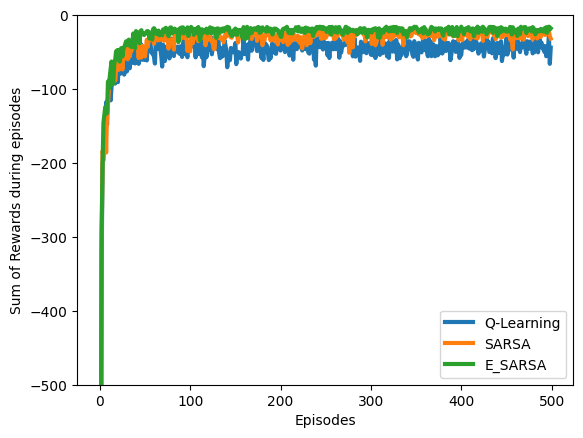

In [191]:
episode_count = 500
sarsa_alg = SARSA()
e_sarsa_alg = E_SARSA()
q_values_runs, rewards_sum_per_episode = sarsa_alg.play(50, episode_count)
ql_agent_run_vals, rewardSums = ql_agent_multiple_runs(50, episode_count, alpha=0.5)
q_values_runs_e, rewards_sum_per_episode_e = e_sarsa_alg.play(50, episode_count)

x = [[i] for i in range(episode_count)]
plt.plot(x, rewardSums, linestyle='-', linewidth=3, label = 'Q-Learning')
plt.plot(x, rewards_sum_per_episode, linestyle='-', linewidth=3, label = 'SARSA')
plt.plot(x, rewards_sum_per_episode_e, linestyle='-', linewidth=3, label = 'E_SARSA')
plt.xlabel('Episodes')
plt.ylabel('Sum of Rewards during episodes')
plt.ylim([-500, 0])
plt.legend()
plt.show()

100%|██████████| 1000/1000 [00:00<00:00, 3430.22it/s]


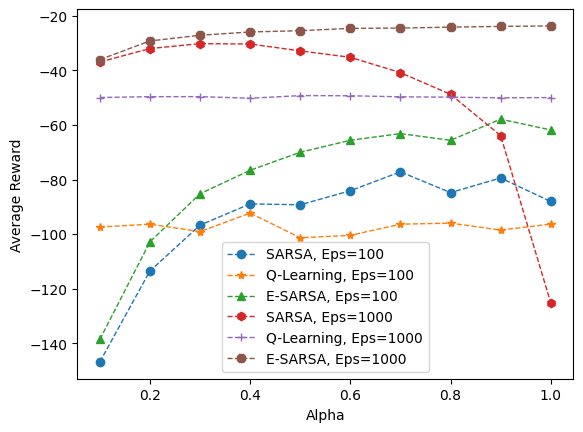

In [196]:
episodes_numbers = [100, 1000]
runs_numbers = [10, 50]

alpha = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1]

marker_groupings = [('o', '*', '^') , ('h', '+', '8')]


for run, episodes, markers in zip(runs_numbers,episodes_numbers, marker_groupings):
    average_rewards_sarsa = []
    average_rewards_q_learning = []
    average_rewards_sarsa_e = []
    for a in alpha:
        sarsa_alg = SARSA(alpha=a)
        e_sarsa_alg = E_SARSA(alpha=a)
        q_values_runs, rewards_sum_per_episode = sarsa_alg.play(run, episodes)
        ql_agent_run_vals, rewardSums = ql_agent_multiple_runs(run, episodes, a)
        q_values_runs_e, rewards_sum_per_episode_e = e_sarsa_alg.play(run, episodes)


        total_sarsa = np.sum(rewards_sum_per_episode)
        average_rewards_sarsa.append( total_sarsa / episodes)

        total_q_learning = np.sum(rewardSums)
        average_rewards_q_learning.append(total_q_learning/episodes)

        total_e_sarsa = np.sum(rewards_sum_per_episode_e)
        average_rewards_sarsa_e.append(total_e_sarsa/episodes)
    plt.plot(alpha, average_rewards_sarsa, marker = markers[0], linestyle='--', linewidth=1, label = 'SARSA, Eps=' + str(episodes))
    plt.plot(alpha, average_rewards_q_learning, marker = markers[1], linestyle='--', linewidth=1, label = 'Q-Learning, Eps=' + str(episodes))
    plt.plot(alpha, average_rewards_sarsa_e, marker = markers[2], linestyle='--', linewidth=1, label = 'E-SARSA, Eps=' + str(episodes))
plt.xlabel('Alpha')
plt.ylabel('Average Reward')

plt.legend()
plt.show()
    

In [ ]:
sarsa_alg = SARSA()
e_sarsa_alg = E_SARSA()
run = 50
episodes = 500
q_values_runs, rewards_sum_per_episode = sarsa_alg.play(run, episodes)
ql_agent_run_vals, rewardSums = ql_agent_multiple_runs(run, episodes, alpha=0.5)
q_values_runs_e, rewards_sum_per_episode_e = e_sarsa_alg.play(run, episodes)



print("SARSA \n")

policy_str = policy_from_value( grid_h,grid_w, actions, q_values_runs, action_symbols)
print(policy_str)

print("Q-Learning \n")
policy_str = policy_from_value( grid_h,grid_w, actions, ql_agent_run_vals, action_symbols)
print(policy_str)

print("E SARSA")
policy_str = policy_from_value( grid_h,grid_w, actions, q_values_runs_e, action_symbols)
print(policy_str)

100%|██████████| 500/500 [00:00<00:00, 4812.14it/s]


TypeError: ql_agent_multiple_runs() missing 1 required positional argument: 'alpha'